In [2]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt


def affine_transform_image(img, M, dsize=None):
    h, w = img.shape[:2]
    if dsize is None:
        dsize = (w, h)
    transformed = cv2.warpAffine(img, M, dsize, borderMode=cv2.BORDER_CONSTANT, borderValue=(0,0,0))
    return transformed

def load_image(paths):
    if isinstance(paths, str):
        paths = [paths]
    for p in paths:
        img = cv2.imread(p)
        if img is not None:
            print(f"Loaded image from: {p}")
            return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return None

def make_synthetic_image():
    img = np.zeros((300, 400, 3), dtype=np.uint8)
    cv2.rectangle(img, (50, 50), (350, 250), (0, 100, 255), -1)
    cv2.circle(img, (200, 150), 70, (255, 255, 0), -1)
    cv2.putText(img, "Test", (120, 160), cv2.FONT_HERSHEY_SIMPLEX, 2, (255,255,255), 3)
    return img

def show_images(images, titles, cols=2):
    rows = int(np.ceil(len(images)/cols))
    fig, axes = plt.subplots(rows, cols, figsize=(8*cols, 6*rows))
    axes = axes.flatten() if len(images) > 1 else [axes]
    for img, title, ax in zip(images, titles, axes):
        ax.imshow(img)
        ax.set_title(title, fontsize=14, weight='bold')
        ax.axis('off')
    for idx in range(len(images), len(axes)):
        axes[idx].axis('off')
    plt.tight_layout()
    plt.show()

print("Notebook initialized")

Notebook initialized


In [3]:
path = 'BMW.jpeg'

In [4]:
img = load_image(path)

if img is None:
    raise FileNotFoundError(
        f"Failed to load image from {path}. "
        "Check the path or use make_synthetic_image() as a fallback."
    )


Loaded image from: BMW.jpeg


Image shape: 720x720


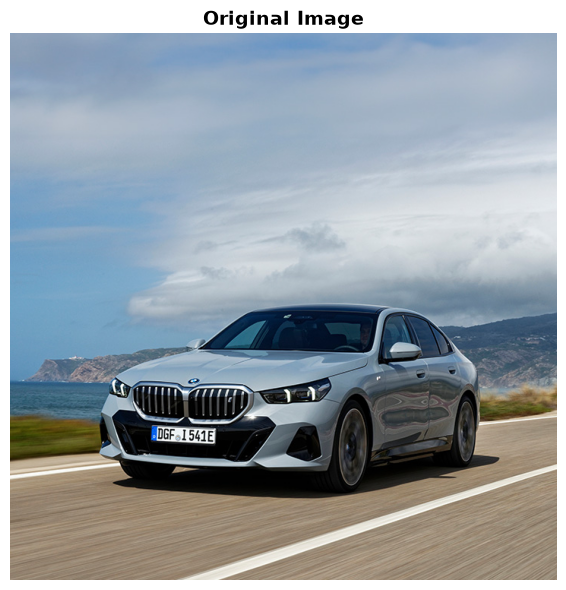

In [5]:

h, w = img.shape[:2]
print(f"Image shape: {w}x{h}")
show_images([img], ["Original Image"], cols=1)

--- Translation Matrix M ---
[[  1.   0.  50.]
 [  0.   1. 100.]]
Shifting image by (50, 100) pixels


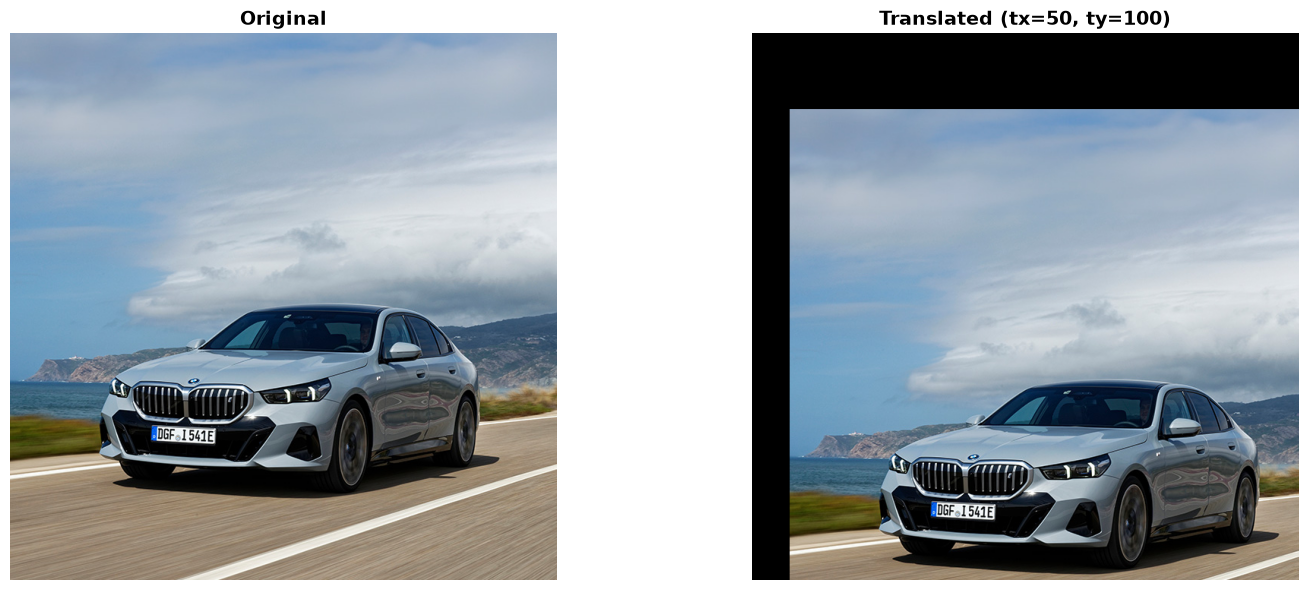

In [6]:
# ============================================================
# 1. TRANSLATION
# Mathematical Foundation:
#   x' = x + tx
#   y' = y + ty
#   T = [ [1, 0, tx],
#         [0, 1, ty],
#         [0, 0, 1 ] ]   (homogeneous 3x3)
# In OpenCV (2x3 affine):
#   T = [ [1, 0, tx],
#         [0, 1, ty] ]
# ============================================================
tx, ty = 50, 100
T = np.float32([[1, 0, tx],
                [0, 1, ty]])

translated = affine_transform_image(img, T)

print("--- Translation Matrix M ---")
print(T)
print(f"Shifting image by ({tx}, {ty}) pixels")
show_images([img, translated], ["Original", f"Translated (tx={tx}, ty={ty})"], cols=2)

--- Rotation Matrix M (2x3 affine from cv2.getRotationMatrix2D) ---
[[   0.70710678    0.70710678 -149.11688245]
 [  -0.70710678    0.70710678  360.        ]]

The 2x3 affine embeds the 2x2 rotation matrix with translation: [45 degrees]
cos(45°) = 0.7071, sin(45°) = 0.7071


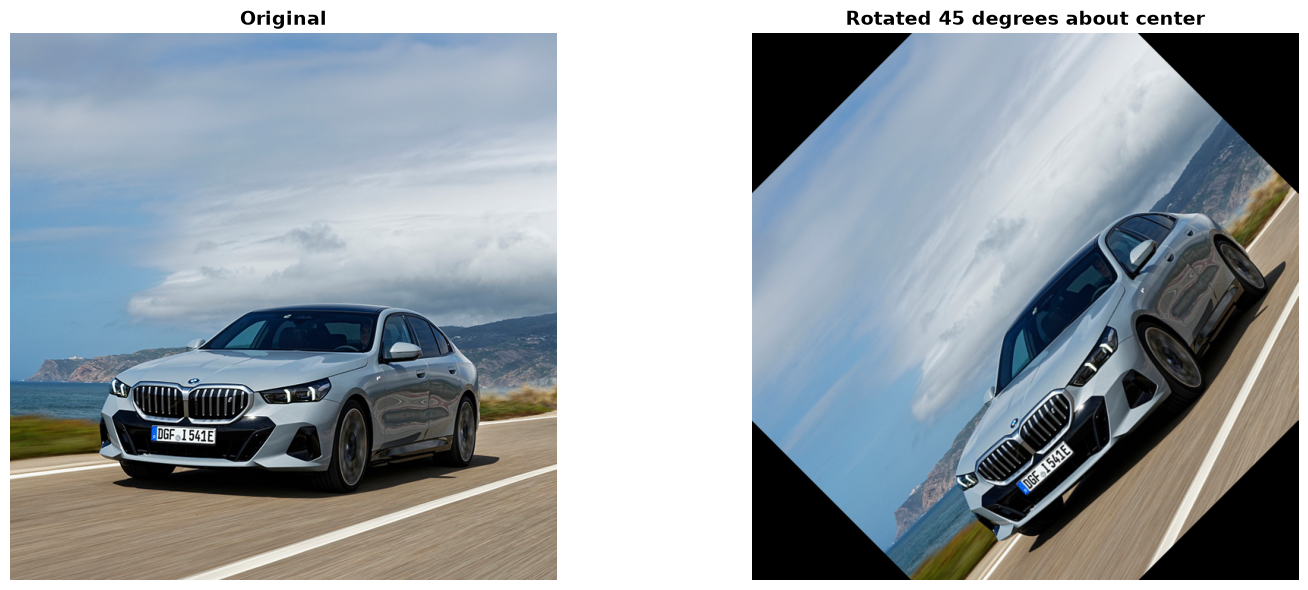

In [7]:
# ============================================================
# 2. ROTATION
# Mathematical Foundation:
#   R(θ) = [ [ cosθ, -sinθ ],
#           [ sinθ,  cosθ ] ]
# Then homogeneous:
#   [ [ cosθ, -sinθ, 0 ],
#     [ sinθ,  cosθ, 0 ],
#     [   0,     0,  1 ] ]
# To rotate about image center, translate back to origin,
# rotate, then translate back to center.
# ============================================================
center = (w/2, h/2)
angle = 45
scale = 1.0
M_rot = cv2.getRotationMatrix2D(center, angle, scale)

rotated = affine_transform_image(img, M_rot)

print("--- Rotation Matrix M (2x3 affine from cv2.getRotationMatrix2D) ---")
print(M_rot)
print(f"\nThe 2x3 affine embeds the 2x2 rotation matrix with translation: [{angle} degrees]")
print(f"cos({angle}°) = {np.cos(np.deg2rad(angle)):.4f}, sin({angle}°) = {np.sin(np.deg2rad(angle)):.4f}")
show_images([img, rotated], ["Original", f"Rotated {angle} degrees about center"], cols=2)

--- Scaling Matrix M ---
[[   1.5    0.  -180. ]
 [   0.     1.5 -180. ]]

Scaling factors: sx=1.5, sy=1.5
About center: center=(360.0, 360.0)


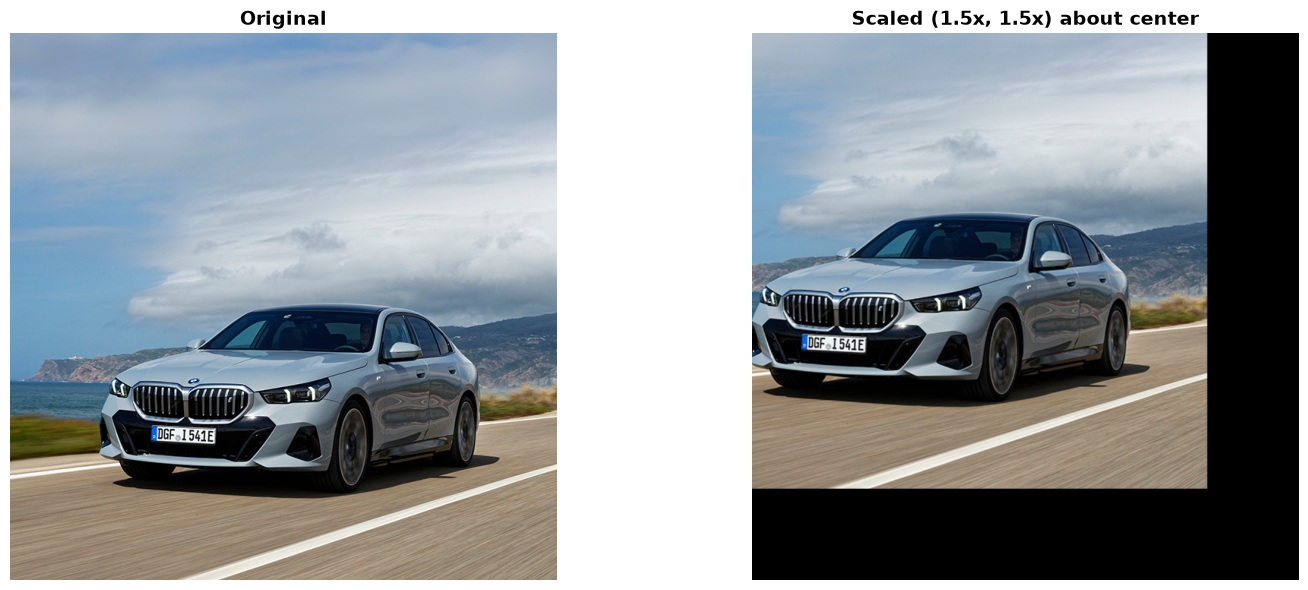

In [8]:
# ============================================================
# 3. SCALING
# Mathematical Foundation:
#   S = [ [ sx,  0  ],
#         [  0,  sy ] ]
# When scaling about image center:
#   S_center = T(c) * S * T(-c)
# ============================================================
sx, sy = 1.5, 1.5
center = (w/2, h/2)
M_scale = cv2.getRotationMatrix2D(center, 0, scale=1.5)
M_scale = np.float32([[sx, 0, (1-sx)*center[0]],
                       [0, sy, (1-sy)*center[1]]])

scaled = affine_transform_image(img, M_scale, dsize=(int(w*sx), int(h*sy)))

print("--- Scaling Matrix M ---")
print(M_scale)
print(f"\nScaling factors: sx={sx}, sy={sy}")
print(f"About center: center=({center[0]}, {center[1]})")
show_images([img, scaled], ["Original", f"Scaled ({sx}x, {sy}x) about center"], cols=2)

--- Combined Transformation Matrix M_total ---
[[   1.03923053    0.60000002 -230.12297443]
 [  -0.60000002    1.03923053  201.87702557]]


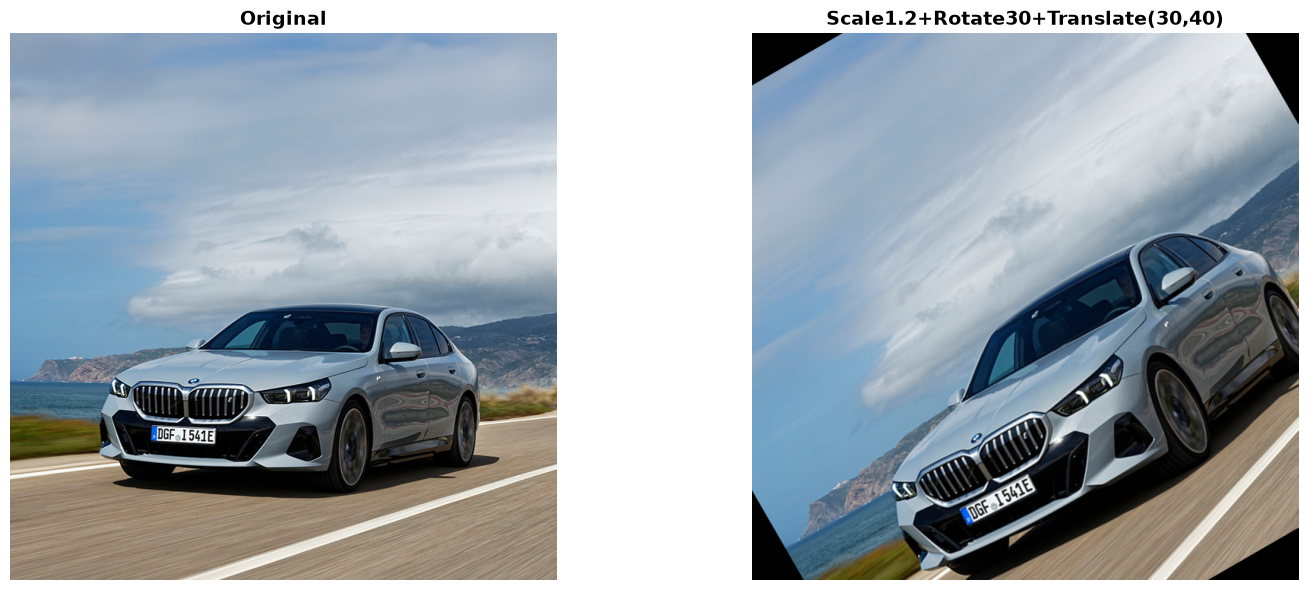

In [9]:
# ============================================================
# 4. COMBINED TRANSFORMATION:
# M_total = T(tx, ty) * R(θ) * S(sx, sy)
# Applied in order: scale -> rotate -> translate
# ============================================================
tx, ty = 30, 40
angle = 30
sx, sy = 1.2, 1.2
center = (w/2, h/2)

M_scale = np.float32([[sx, 0, (1-sx)*center[0]],
                       [0, sy, (1-sy)*center[1]]])
M_rot = cv2.getRotationMatrix2D(center, angle, 1.0)
T = np.float32([[1, 0, tx],
                [0, 1, ty]])

M_total = np.vstack([np.hstack([M_rot[:,:2] @ M_scale[:,:2], M_rot[:,:2] @ M_scale[:,2].reshape(2,1) + M_rot[:,2].reshape(2,1)]), [0,0,1]])
M_total = M_total[:2, :]

combined = affine_transform_image(img, M_total)

print("--- Combined Transformation Matrix M_total ---")
print(M_total)
show_images([img, combined], ["Original", f"Scale{sx}+Rotate{angle}+Translate({tx},{ty})"], cols=2)